In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers,models, optimizers
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/creditcard.csv')

In [ ]:
df.head(-4)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,...,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0


In [ ]:
features = df.iloc[:,:-1].values
target = df.iloc[:,-1].values

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(features,target,test_size =0.2,stratify = target,random_state = 42)

In [ ]:
#select only normal data from training
x_train_normal = x_train[y_train == 1]

In [ ]:
#scale the data
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train_normal)
x_test_scaled = scaler.transform(x_test)

In [ ]:
#defince autoencoder
class Autoencoder(models.Model):
  def __init__(self,output_units):
    super().__init__()

    self.encoder = models.Sequential([
        layers.Dense(64,activation='relu'),
        layers.Dense(32,activation='relu'),
        layers.Dense(16,activation='relu'),
        layers.Dense(8,activation='relu')
    ])

    self.decoder = models.Sequential([
        layers.Dense(16,activation='relu'),
        layers.Dense(32,activation='relu'),
        layers.Dense(64,activation='relu'),
        layers.Dense(output_units,activation='sigmoid')
    ])

  def call(self,inputs):
    encoded = self.encoder(inputs)
    decoded = self.decoder(encoded)
    return decoded

In [ ]:
x_train_scaled.shape[1]

30

In [ ]:
#compile the model
model = Autoencoder(output_units = x_train_scaled.shape[1])
model.compile(
    optimizer='adam',
    loss='msle',
    metrics=['mse']
)

history = model.fit(
    x_train_scaled,x_train_scaled,
    batch_size =512,
    epochs = 20,
    verbose =1,
    validation_data = (x_test_scaled,x_test_scaled)
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 0.0262 - mse: 0.0578 - val_loss: 0.0357 - val_mse: 0.0832
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 733ms/step - loss: 0.0260 - mse: 0.0573 - val_loss: 0.0355 - val_mse: 0.0827
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - loss: 0.0258 - mse: 0.0570 - val_loss: 0.0353 - val_mse: 0.0823
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - loss: 0.0257 - mse: 0.0567 - val_loss: 0.0352 - val_mse: 0.0820
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 0.0257 - mse: 0.0566 - val_loss: 0.0350 - val_mse: 0.0817
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - loss: 0.0256 - mse: 0.0564 - val_loss: 0.0349 - val_mse: 0.0813
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - loss: 0.0255 - mse: 0.0562 - val_loss: 0.0347 - val_mse: 0.0810
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - loss: 0.0254 - mse: 0.0559 - val_loss: 0.0346 - val_mse: 0.0806
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 0.0253 - mse: 0.0

In [ ]:
#find threshold
def find_threshold(model,x_train_scaled):
  reconstructions = model.predict(x_train_scaled)
  reconstruction_error = tf.keras.losses.msle(reconstructions,x_train_scaled)
  threshold =  np.mean(reconstruction_error.numpy()) + np.std(reconstruction_error.numpy())
  return threshold

In [ ]:
threshold  = find_threshold(model,x_train_scaled)
print(threshold)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
0.0306100786311101


In [ ]:
#predict and check accuracy for test data
reconstructions = model.predict(x_test_scaled)
reconstruction_error = tf.keras.losses.msle(reconstructions,x_test_scaled)
y_pred = np.where(reconstruction_error>threshold,0,1)
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
0.4665742073663144


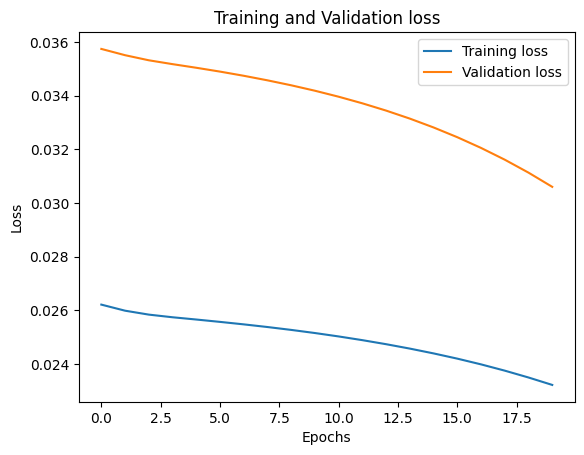

In [ ]:
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Training and Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
model.summary()

Model: "autoencoder_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 8)              │         4,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 30)             │         4,750 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,436 (111.08 KB)

 Trainable params: 9,478 (37.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,958 (74.06 KB)